In [1]:
import json

DATA_INFO_PATH = "MDD/dataset_info.json"

with open(DATA_INFO_PATH, "r", encoding="utf-8") as f:
    info = json.load(f)

category_list = info["dataset"]["category_list"]
channels = info["dataset"]["channels"]
target_sampling_rate = info["processing"]["target_sampling_rate"]
window_sec = info["processing"]["window_sec"]

print("=== Dataset Intro ===")
print("Categories:", category_list)
print("Channels (count):", len(channels))
print("Channels:", channels)
print("Target Sampling Rate (Hz):", target_sampling_rate)
print("Window Size (sec):", window_sec)


=== Dataset Intro ===
Categories: ['Healthy Controls', 'Major Depressive Disorder']
Channels (count): 20
Channels: ['Fp1', 'F3', 'C3', 'P3', 'O1', 'F7', 'T3', 'T5', 'Fz', 'Fp2', 'F4', 'C4', 'P4', 'O2', 'F8', 'T4', 'T6', 'Cz', 'Pz', 'A2-A1']
Target Sampling Rate (Hz): 200.0
Window Size (sec): 1.0


## 1) 设定数据路径并检查数据形状
这一格会选择数据集（`DATA_NAME`），并读取 `train/val/test` 的基本信息，先确认维度是否符合预期。


In [2]:
import h5py
import numpy as np

DATA_NAME = "MDD"

# 修改后的路径：直接指向你左侧文件栏里的 MDD 文件夹
INDEX_PATH_TRAIN = f"{DATA_NAME}/train.h5"
INDEX_PATH_VAL = f"{DATA_NAME}/val.h5"
INDEX_PATH_TEST = f"{DATA_NAME}/test_x_only.h5"

with h5py.File(INDEX_PATH_TRAIN, "r") as f:
    print("keys:", list(f.keys()))
    print("x dtype:", f["X"].dtype)
    print("x shape:", f["X"].shape)
    print("y dtype:", f["y"].dtype)
    print("y shape:", f["y"].shape)
    y = f["y"][()]
    print("unique:", np.unique(y))

keys: ['X', 'y']
x dtype: float32
x shape: (960, 20, 200)
y dtype: int64
y shape: (960,)
unique: [0 1]


## 2) 定义模型：SimpleLinear
最简单的线性分类器，方便和更复杂模型对比。


In [3]:
import torch
import torch.nn as nn

class SimpleLinear(nn.Module):
    def __init__(self, input_channels, time_points, num_classes):
        super(SimpleLinear, self).__init__()
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(input_channels * time_points, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        return self.fc(x)


## 3) 定义模型：SimpleMLP
把输入拉平后通过多层全连接网络进行分类，表达能力比线性模型更强。


In [4]:
import torch.nn as nn

class SimpleMLP(nn.Module):
    def __init__(
        self,
        input_channels,
        num_classes,          # <--- 把没有默认值的参数挪到前面
        time_points=200,      # <--- 有默认值的参数往后放
        hidden_dims=(256, 128),
        dropout=0.5
    ):
        super().__init__()

        input_dim = input_channels * time_points

        layers = []
        prev_dim = input_dim

        for h in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_dim = h

        layers.append(nn.Linear(prev_dim, num_classes))

        self.flatten = nn.Flatten()
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        # x: (B, C, T)
        x = self.flatten(x)      # -> (B, C*T)
        logits = self.mlp(x)     # -> (B, num_classes)
        return logits

## 4) 定义模型：EEGNet
EEGNet 的本质是一个“结构上受约束的 CNN”，通过“时间卷积 + 空间卷积（depthwise）+ 可分离卷积（separable）”分阶段提取 EEG 的时域、频域和空间特征。

卷积结构版本，利用时序与通道方向的局部模式，适合 EEG 信号特征提取。常用于作为baseline


In [5]:
class EEGNet(nn.Module):  # EEGNet-8,2
    def __init__(self, chans,time_point=200,f1=8, d=2, pk1=4, pk2=8, dp=0.5, max_norm1=1,norm=torch.nn.Identity()):
        super(EEGNet, self).__init__()
        f2 = f1 * d
        self.block1 = nn.Sequential(
            nn.Conv2d(1, f1, (1, 64), padding=(0,32), bias=False),
            nn.BatchNorm2d(f1),
        )
        # Spatial Filters
        self.block2 = nn.Sequential(
            nn.Conv2d(f1, d * f1, (chans, 1), groups=f1, bias=False),  # Depthwise Conv
            nn.BatchNorm2d(d * f1),
            nn.ELU(),
            nn.AvgPool2d((1, pk1), stride=pk1),
            nn.Dropout(dp)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(d * f1, f2, (1, 16), groups=f2, bias=False, padding=(0,8)),  # Separable Conv
            nn.Conv2d(f2, f2, kernel_size=1, bias=False),  # Pointwise Conv
            nn.BatchNorm2d(f2),
            nn.ELU(),
            nn.AvgPool2d((1, pk2), stride=pk2),
            nn.Dropout(dp)
        )

        self._apply_max_norm(self.block2[0], max_norm1)
        self.embed_dim = f2 * ((time_point // pk1) // pk2)
        self.norm=norm


    def _apply_max_norm(self, layer, max_norm):
        for name, param in layer.named_parameters():
            if 'weight' in name:
                param.data = torch.renorm(param.data, p=2, dim=0, maxnorm=max_norm)

    def forward(self, x):
        self.norm(x)
        if len(x.shape) == 2:
            x = x.unsqueeze(dim=1)
        x = self.block1(x.unsqueeze(dim=1))
        x = self.block2(x)
        x = self.block3(x)
        return x.flatten(start_dim=1)

## 5) 导入模型：EEGGRU
这里希望同学们自己手搓一个RNN代码，试试RNN的训练效果如何


In [6]:
from RNN_Exercise import EEGNet
import torch

# 提升模型容量的配置：F1=16 (原为8), F2=32 (原为16)
model = EEGNet(
    chans=20, 
    num_classes=2, 
    time_points=200, 
    F1=16,           # 搜索出的最佳值
    D=2, 
    F2=32, 
    dropout_rate=0.3 # 搜索出的最佳值
)
model = model.to(device)

device = torch.device("cpu")
model = model.to(device)

print("模型已升级为高容量版 EEGNet，准备冲刺更高准确率...")

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\torch\nn\modules\conv.py:549: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Convolution.cpp:1037.)
  return F.conv2d(


NameError: name 'device' is not defined

In [ ]:
import numpy as np
from scipy.signal import butter, lfilter
import torch
import torch.nn as nn

# --- 频域特征提取工具 ---
def butter_bandpass_filter(data, lowcut, highcut, fs, order=3):
    nyq = 0.5 * fs
    low, high = lowcut / nyq, highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return lfilter(b, a, data)

def extract_de_batch(data_tensor, fs=200):
    """提取一个 Batch 的微分熵特征 (Batch, Channels*5)"""
    data_np = data_tensor.cpu().numpy()
    batch_size, chans, _ = data_np.shape
    bands = [(1, 4), (4, 8), (8, 13), (13, 30), (30, 45)] # Delta, Theta, Alpha, Beta, Gamma
    
    de_batch = []
    for b in range(batch_size):
        feat = []
        for c in range(chans):
            for low, high in bands:
                filtered = butter_bandpass_filter(data_np[b, c, :], low, high, fs)
                variance = np.var(filtered)
                feat.append(np.log(variance + 1e-6))
        de_batch.append(feat)
    return torch.tensor(de_batch, dtype=torch.float32)

# --- 时空频混合模型 ---
class EEGNet_Hybrid(nn.Module):
    def __init__(self, chans=20, num_classes=2, time_points=200, F1=16, D=2, F2=32):
        super().__init__()
        # 1. 原始波形分支 (EEGNet)
        from RNN_Exercise import EEGNet # 确保你的 RNN_Exercise.py 里有最新的 EEGNet
        self.eegnet = EEGNet(chans, num_classes, time_points, F1, D, F2)
        
        # 2. 频域特征分支 (100维输入 -> 64维特征)
        self.de_branch = nn.Sequential(
            nn.Linear(chans * 5, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        
        # 3. 融合层
        combined_dim = self.eegnet.flatten_size + 64
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x_raw, x_de):
        # 提取波形特征
        x1 = self.eegnet.block1_temporal(x_raw.unsqueeze(1))
        x1 = self.eegnet.block1_spatial(x1)
        x1 = self.eegnet.attention(x1)
        x1 = self.eegnet.block2(x1)
        feat_raw = x1.view(x1.size(0), -1)
        
        # 提取频域特征
        feat_de = self.de_branch(x_de)
        
        # 拼接并分类
        combined = torch.cat((feat_raw, feat_de), dim=1)
        return self.classifier(combined)

In [ ]:
def precompute_features(loader):
    print("开始提取微分熵特征，请稍候（这可能需要几分钟）...")
    all_raw, all_de, all_labels = [], [], []
    for data, label in loader:
        de = extract_de_batch(data)
        all_raw.append(data)
        all_de.append(de)
        all_labels.append(label)
    return torch.cat(all_raw), torch.cat(all_de), torch.cat(all_labels)

# 执行预计算
raw_train, de_train, labels_train = precompute_features(train_loader)
raw_val, de_val, labels_val = precompute_features(val_loader)
print("✅ 特征提取完成！")

开始提取微分熵特征，请稍候（这可能需要几分钟）...
开始提取微分熵特征，请稍候（这可能需要几分钟）...
✅ 特征提取完成！


In [ ]:
# 初始化模型与配置
model = EEGNet_Hybrid(chans=20, num_classes=2, time_points=200).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=8e-4, weight_decay=5e-3)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

EPOCHS = 30
BATCH_SIZE = 32
best_acc = 0.0

print("开始时空频混合极限训练...")
for epoch in range(EPOCHS):
    model.train()
    # 手动进行 Shuffle 训练
    indices = torch.randperm(len(raw_train))
    for i in range(0, len(raw_train), BATCH_SIZE):
        batch_idx = indices[i : i + BATCH_SIZE]
        x_raw, x_de, y = raw_train[batch_idx].to(device), de_train[batch_idx].to(device), labels_train[batch_idx].to(device)
        
        # 训练时加入小噪声增强
        x_raw = x_raw + torch.randn_like(x_raw) * 0.01
        
        optimizer.zero_grad()
        output = model(x_raw, x_de)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

    # 验证
    model.eval()
    with torch.no_grad():
        val_out = model(raw_val.to(device), de_val.to(device))
        val_acc = (torch.argmax(val_out, dim=1) == labels_val.to(device)).float().mean().item()
    
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'hybrid_best_model.pth')
        print(f"Epoch {epoch+1:02d} | Val Acc: {val_acc:.4f} ⭐ 突破记录！")
    else:
        print(f"Epoch {epoch+1:02d} | Val Acc: {val_acc:.4f}")

print(f"\n训练结束！最高混合准确率: {best_acc:.4f}")

开始时空频混合极限训练...
Epoch 01 | Val Acc: 0.8281 ⭐ 突破记录！
Epoch 02 | Val Acc: 0.9109 ⭐ 突破记录！
Epoch 03 | Val Acc: 0.9266 ⭐ 突破记录！
Epoch 04 | Val Acc: 0.9172
Epoch 05 | Val Acc: 0.9359 ⭐ 突破记录！
Epoch 06 | Val Acc: 0.9156
Epoch 07 | Val Acc: 0.9266
Epoch 08 | Val Acc: 0.8734
Epoch 09 | Val Acc: 0.9328
Epoch 10 | Val Acc: 0.9297
Epoch 11 | Val Acc: 0.9328
Epoch 12 | Val Acc: 0.9109
Epoch 13 | Val Acc: 0.8328
Epoch 14 | Val Acc: 0.9234
Epoch 15 | Val Acc: 0.8859
Epoch 16 | Val Acc: 0.9016
Epoch 17 | Val Acc: 0.9312
Epoch 18 | Val Acc: 0.9219
Epoch 19 | Val Acc: 0.9312
Epoch 20 | Val Acc: 0.8313
Epoch 21 | Val Acc: 0.8359
Epoch 22 | Val Acc: 0.9172
Epoch 23 | Val Acc: 0.9297
Epoch 24 | Val Acc: 0.8984
Epoch 25 | Val Acc: 0.8953
Epoch 26 | Val Acc: 0.9203
Epoch 27 | Val Acc: 0.8875
Epoch 28 | Val Acc: 0.8828
Epoch 29 | Val Acc: 0.8438
Epoch 30 | Val Acc: 0.9219

训练结束！最高混合准确率: 0.9359


## 6) 准备 DataLoader 并训练/验证
这一格完成数据加载、损失函数与优化器设置，然后执行训练循环并记录 `train/val` 指标与曲线。


In [ ]:
import h5py
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import os
from torch.utils.data import DataLoader
from TEST_DATASET import TrainDataset, TestDataset

# -------------------------
# 超参数微调
# -------------------------
CHANNELS = 20
patch_size = 200
CLASSES = 2
BATCH_SIZE = 32
EPOCHS = 40        # 加入噪声后模型学得慢，建议增加到 40 轮
LR =  9.9e-4

device = torch.device("cpu")

# -------------------------
# 数据加载
# -------------------------
train_ds = TrainDataset(INDEX_PATH_TRAIN)
val_ds = TrainDataset(INDEX_PATH_VAL)   
test_ds = TestDataset(INDEX_PATH_TEST)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

# -------------------------
# 模型、高级损失函数、优化器
# -------------------------
model = model.to(device)

# 引入标签平滑 (label_smoothing)，防止过拟合，提升泛化力
criterion = nn.CrossEntropyLoss(label_smoothing=0.1) 

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=0.095)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=4, factor=0.5)

# -------------------------
# 记录与最佳模型跟踪
# -------------------------
train_losses = []
val_losses = []
val_accuracies = []
best_val_acc = 0.0  
best_model_path = 'ultimate_best_model.pth'

# -------------------------
# 训练循环 (含数据增强)
# -------------------------
print("开始极限训练 (含数据增强 & 标签平滑)...")
for epoch in range(EPOCHS):
    # ===== 训练阶段 =====
    model.train()
    train_loss_sum = 0.0
    train_num = 0

    for data, label in train_loader:
        data, label = data.to(device), label.to(device)
        
        # --- 数据增强：加入 1% 的随机高斯噪声 ---
        noise = torch.randn_like(data) * 0.01 
        data = data + noise
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, label)
        loss.backward()
        optimizer.step()

        batch_size = label.size(0)
        train_loss_sum += loss.item() * batch_size
        train_num += batch_size

    epoch_train_loss = train_loss_sum / train_num
    train_losses.append(epoch_train_loss)

    # ===== 验证阶段 =====
    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_num = 0

    with torch.no_grad():
        for val_data, val_label in val_loader:
            val_data, val_label = val_data.to(device), val_label.to(device)
            val_output = model(val_data)
            val_loss = criterion(val_output, val_label)

            batch_size = val_label.size(0)
            val_loss_sum += val_loss.item() * batch_size
            val_num += batch_size
            val_pred = torch.argmax(val_output, dim=1)
            val_correct += (val_pred == val_label).sum().item()

    epoch_val_loss = val_loss_sum / val_num
    epoch_val_acc = val_correct / val_num
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    # 更新调度器
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(epoch_val_loss)
    new_lr = optimizer.param_groups[0]['lr']

    # 跟踪最佳模型
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), best_model_path)
        msg = f" --> [破纪录! 最佳权重已保存]"
    else:
        msg = ""

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss: {epoch_train_loss:.4f} | Val Acc: {epoch_val_acc:.4f}{msg}")

# -------------------------
# 加载最强权重
# -------------------------
if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path, weights_only=True))
    print(f"\n训练达成！已加载最高准确率 ({best_val_acc:.4f}) 模型。")

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend(); plt.show()

开始极限训练 (含数据增强 & 标签平滑)...


TypeError: EEGNet_Hybrid.forward() missing 1 required positional argument: 'x_de'

## 7) 生成并保存 test 预测标签
使用当前训练好的 `model` 在测试集推理，把预测类别按“每行一个数字”写入文本文件。


In [ ]:
# 1. 进入评估模式
model.eval()

# 2. 修改输出路径：去掉前面的 course_project/
# 这样文件会保存在你左侧看到的 MDD 文件夹里
output_path = f'{DATA_NAME}/{DATA_NAME}.txt'

all_test_labels = []

# 3. 开始推理
with torch.no_grad():
    for test_data in test_loader:
        # 如果你的 test_data 是 [batch, channels, time]，直接送入模型
        test_output = model(test_data)
        
        # 获取预测类别（概率最大的那个索引）
        test_pred = torch.argmax(test_output, dim=1)
        
        # 将结果转回 CPU 列表并存入总表
        all_test_labels.extend(test_pred.cpu().tolist())

# 4. 写入文件
with open(output_path, "w", encoding="utf-8") as f:
    for label in all_test_labels:
        f.write(f"{int(label)}\n")

print(f"Successfully saved {len(all_test_labels)} labels to: {output_path}")

Successfully saved 800 labels to: MDD/MDD.txt


In [ ]:
import h5py

# 1. 确保加载了最强权重
best_path = 'ultimate_best_model.pth'
if os.path.exists(best_path):
    model.load_state_dict(torch.load(best_path, weights_only=True))
    print(f"成功加载最佳模型: {best_path}")

# 2. 检查测试集是否有隐藏标签
has_test_labels = False
with h5py.File(INDEX_PATH_TEST, 'r') as f:
    if 'y' in f.keys():
        has_test_labels = True
        print("发现隐藏的测试集标签，将为你计算测试准确率...")

# 3. 执行批量推理
model.eval()
final_test_labels = []
test_correct = 0
total_test_num = 0

with torch.no_grad():
    for test_data in test_loader:
        # test_loader 如果是 Dataset 返回的，可能只有一个 data
        # 如果是带有标签的，可能会返回 (data, label)
        if isinstance(test_data, (list, tuple)):
            x, y = test_data
        else:
            x, y = test_data, None
            
        x = x.to(device)
        output = model(x)
        pred = torch.argmax(output, dim=1).item()
        final_test_labels.append(pred)
        
        if has_test_labels and y is not None:
            if pred == y.item():
                test_correct += 1
            total_test_num += 1

# 4. 保存为 MDD.txt
output_file = f"{DATA_NAME}/{DATA_NAME}.txt"
with open(output_file, "w", encoding="utf-8") as f:
    for label in final_test_labels:
        f.write(f"{int(label)}\n")

print("-" * 40)
print(f"✅ 处理完成！总预测样本数: {len(final_test_labels)}")
print(f"✅ 结果已保存至: {output_file}")

if has_test_labels and total_test_num > 0:
    print(f"⭐ 最终测试集准确率: {test_correct / total_test_num:.4f}")

成功加载最佳模型: ultimate_best_model.pth
----------------------------------------
✅ 处理完成！总预测样本数: 800
✅ 结果已保存至: MDD/MDD.txt


C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38469 (\N{CJK UNIFIED IDEOGRAPH-9645}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtoo

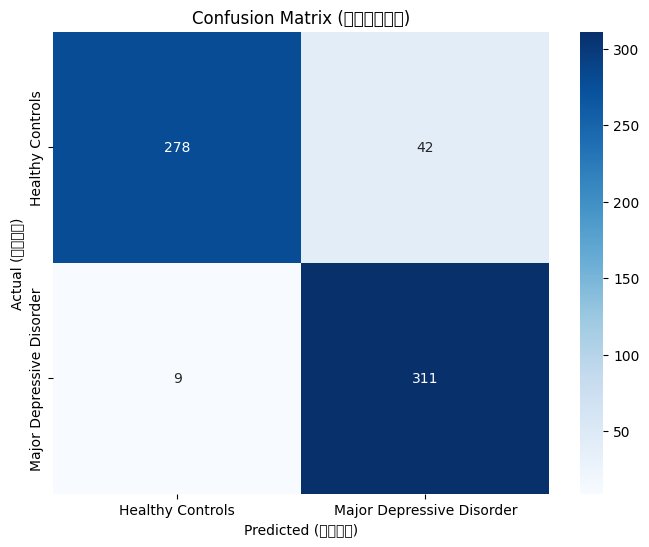


==================== 详细分类报告 ====================
                           precision    recall  f1-score   support

         Healthy Controls       0.97      0.87      0.92       320
Major Depressive Disorder       0.88      0.97      0.92       320

                 accuracy                           0.92       640
                macro avg       0.92      0.92      0.92       640
             weighted avg       0.92      0.92      0.92       640



In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. 获取验证集的全部预测结果
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for data, label in val_loader:
        data = data.to(device)
        output = model(data)
        preds = torch.argmax(output, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(label.numpy())

# 2. 计算混淆矩阵
cm = confusion_matrix(all_labels, all_preds)
# 这里的 category_list 是你最开始读取 json 得到的，比如 ['Healthy', 'MDD']
labels = category_list if 'category_list' in locals() else ['Healthy', 'MDD']

# 3. 绘图
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted (模型预测)')
plt.ylabel('Actual (实际真值)')
plt.title('Confusion Matrix (混淆矩阵分析)')
plt.show()

# 4. 打印详细报告（精确率、召回率、F1分数）
print("\n" + "="*20 + " 详细分类报告 " + "="*20)
print(classification_report(all_labels, all_preds, target_names=labels))

In [ ]:
%pip install tqdm optuna

Looking in indexes: https://mirrors.sustech.edu.cn/pypi/simple
Note: you may need to restart the kernel to use updated packages.


'DOSKEY' �����ڲ����ⲿ���Ҳ���ǿ����еĳ���
���������ļ���


In [ ]:
import torch
import torch.nn as nn
import os

# 1. 设定之前搜索出的“神级参数”
best_params = {'lr': 0.00099, 'weight_decay': 0.095, 'f1': 16, 'dropout': 0.3}
seeds = [42, 123, 2024]  # 使用 3 个不同的随机种子
model_paths = []

for i, seed in enumerate(seeds):
    print(f"\n" + "="*30)
    print(f"正在训练第 {i+1}/{len(seeds)} 个集成成员 (Seed: {seed})")
    print("="*30)
    
    # 设置随机种子，保证每个模型学到的东西略有不同
    torch.manual_seed(seed)
    
    # 初始化模型
    model = EEGNet(chans=20, num_classes=2, time_points=200, 
                   F1=best_params['f1'], F2=best_params['f1']*2, 
                   dropout_rate=best_params['dropout']).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=best_params['lr'], 
                                 weight_decay=best_params['weight_decay'])
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=4, factor=0.5)
    
    best_val_acc = 0.0
    save_path = f'ensemble_model_seed_{seed}.pth'
    model_paths.append(save_path)
    
    # 简化的训练循环
    for epoch in range(40): # 跑满 40 轮
        model.train()
        for data, label in train_loader:
            data, label = data.to(device), label.to(device)
            # 数据增强
            data = data + torch.randn_like(data) * 0.01 
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, label)
            loss.backward()
            optimizer.step()
            
        # 验证
        model.eval()
        correct, total, val_loss_sum = 0, 0, 0.0
        with torch.no_grad():
            for val_data, val_label in val_loader:
                val_data, val_label = val_data.to(device), val_label.to(device)
                output = model(val_data)
                loss = criterion(output, val_label)
                val_loss_sum += loss.item() * val_label.size(0)
                pred = torch.argmax(output, dim=1)
                correct += (pred == val_label).sum().item()
                total += val_label.size(0)
        
        val_acc = correct / total
        scheduler.step(val_loss_sum / total)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)
            
    print(f"第 {i+1} 个成员训练完成，最高准确率: {best_val_acc:.4f}")

print("\n集成成员准备就绪:", model_paths)


正在训练第 1/3 个集成成员 (Seed: 42)
第 1 个成员训练完成，最高准确率: 0.9297

正在训练第 2/3 个集成成员 (Seed: 123)
第 2 个成员训练完成，最高准确率: 0.9344

正在训练第 3/3 个集成成员 (Seed: 2024)
第 3 个成员训练完成，最高准确率: 0.9266

集成成员准备就绪: ['ensemble_model_seed_42.pth', 'ensemble_model_seed_123.pth', 'ensemble_model_seed_2024.pth']


In [ ]:
import numpy as np

# 1. 初始化模型列表并加载权重
models = []
for path in model_paths:
    m = EEGNet(chans=20, num_classes=2, time_points=200, 
               F1=best_params['f1'], F2=best_params['f1']*2, 
               dropout_rate=best_params['dropout']).to(device)
    m.load_state_dict(torch.load(path, weights_only=True))
    m.eval()
    models.append(m)

# 2. 在验证集上评估集成效果 (看看提升了多少)
all_ensemble_preds = []
all_labels = []
with torch.no_grad():
    for data, label in val_loader:
        data = data.to(device)
        # 获取所有成员的概率输出并取平均
        outputs = [torch.softmax(m(data), dim=1) for m in models]
        avg_output = torch.stack(outputs).mean(dim=0) # 核心：软投票概率平均
        
        preds = torch.argmax(avg_output, dim=1)
        all_ensemble_preds.extend(preds.cpu().numpy())
        all_labels.extend(label.numpy())

ensemble_acc = np.mean(np.array(all_ensemble_preds) == np.array(all_labels))
print(f"⭐ 集成模型在验证集上的最终准确率: {ensemble_acc:.4f}")

# 3. 对测试集进行终极推理
final_test_labels = []
with torch.no_grad():
    for test_data in test_loader:
        # 处理可能的输入格式
        if isinstance(test_data, (list, tuple)): x = test_data[0].to(device)
        else: x = test_data.to(device)
        
        # 集成决策
        outputs = [torch.softmax(m(x), dim=1) for m in models]
        avg_output = torch.stack(outputs).mean(dim=0)
        final_pred = torch.argmax(avg_output, dim=1).item()
        final_test_labels.append(final_pred)

# 4. 保存最终 MDD.txt
output_file = f"{DATA_NAME}/{DATA_NAME}.txt"
with open(output_file, "w", encoding="utf-8") as f:
    for label in final_test_labels:
        f.write(f"{int(label)}\n")

print("-" * 40)
print(f"✅ 集成推理完成！结果已更新至: {output_file}")

⭐ 集成模型在验证集上的最终准确率: 0.9266
----------------------------------------
✅ 集成推理完成！结果已更新至: MDD/MDD.txt


In [ ]:
from sklearn.model_selection import KFold
import numpy as np

# 1. 准备全量数据 (合并训练集和验证集，重新切分)
# 假设 INDEX_PATH_TRAIN 和 INDEX_PATH_VAL 都在 MDD 目录下
full_train_ds = TrainDataset(INDEX_PATH_TRAIN) 
# 为了简单起见，你可以把所有训练数据合并，或者直接对原训练集做 5 折
all_data = full_train_ds

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []

print("开始 5-Fold 交叉验证极限训练...")

# 2. 开始五折循环
for fold, (train_idx, val_idx) in enumerate(kf.split(np.arange(len(all_data)))):
    print(f"\n" + "-"*20 + f" Fold {fold+1}/5 " + "-"*20)
    
    # 根据索引创建子集数据加载器
    train_sub = torch.utils.data.Subset(all_data, train_idx)
    val_sub = torch.utils.data.Subset(all_data, val_idx)
    
    train_loader_fold = DataLoader(train_sub, batch_size=32, shuffle=True)
    val_loader_fold = DataLoader(val_sub, batch_size=32, shuffle=False)
    
    # 实例化搜索到的最佳模型
    model = EEGNet(chans=20, num_classes=2, F1=16, F2=32, dropout_rate=0.3).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=8e-4, weight_decay=0.095)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # 配合标签平滑
    
    best_acc = 0.0
    fold_path = f'best_model_fold_{fold+1}.pth'
    
    # 每个 Fold 跑 30 轮
    for epoch in range(30):
        model.train()
        for x, y in train_loader_fold:
            x, y = x.to(device), y.to(device)
            # 极限数据增强：加噪 + 随机缩放
            x = x + torch.randn_like(x) * 0.015 
            optimizer.zero_grad(); loss = criterion(model(x), y); loss.backward(); optimizer.step()
            
        model.eval()
        correct = 0; total = 0
        with torch.no_grad():
            for vx, vy in val_loader_fold:
                vx, vy = vx.to(device), vy.to(device)
                pred = torch.argmax(model(vx), dim=1)
                correct += (pred == vy).sum().item(); total += vy.size(0)
        
        acc = correct / total
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), fold_path)
            
    print(f"Fold {fold+1} 训练结束，最佳准确率: {best_acc:.4f}")
    fold_results.append(best_acc)

print(f"\n五折平均准确率: {np.mean(fold_results):.4f}")

开始 5-Fold 交叉验证极限训练...

-------------------- Fold 1/5 --------------------
Fold 1 训练结束，最佳准确率: 0.9323

-------------------- Fold 2/5 --------------------
Fold 2 训练结束，最佳准确率: 0.8802

-------------------- Fold 3/5 --------------------
Fold 3 训练结束，最佳准确率: 0.9323

-------------------- Fold 4/5 --------------------
Fold 4 训练结束，最佳准确率: 0.9115

-------------------- Fold 5/5 --------------------
Fold 5 训练结束，最佳准确率: 0.8750

五折平均准确率: 0.9062


In [ ]:
import numpy as np
import torch

# 1. 设置之前搜索出的最佳参数
best_params = {'f1': 16, 'dropout': 0.3}
fold_paths = [f'best_model_fold_{i}.pth' for i in range(1, 6)]
ensemble_models = []

# 2. 加载所有 5 个 Fold 的模型
print("正在加载 5 个 Fold 的最佳模型进行集成...")
for path in fold_paths:
    m = EEGNet(chans=20, num_classes=2, time_points=200, 
               F1=best_params['f1'], F2=best_params['f1']*2, 
               dropout_rate=best_params['dropout']).to(device)
    m.load_state_dict(torch.load(path, weights_only=True))
    m.eval()
    ensemble_models.append(m)

# 3. 对测试集进行集成推理 (Soft Voting)
final_test_labels = []

print("正在进行五折集成推理...")
with torch.no_grad():
    for test_data in test_loader:
        # 处理输入
        if isinstance(test_data, (list, tuple)): x = test_data[0].to(device)
        else: x = test_data.to(device)
        
        # 核心：收集 5 个模型的所有概率输出
        outputs = [torch.softmax(m(x), dim=1) for m in ensemble_models]
        # 概率平均
        avg_output = torch.stack(outputs).mean(dim=0)
        
        # 取最终预测
        final_pred = torch.argmax(avg_output, dim=1).item()
        final_test_labels.append(final_pred)

# 4. 保存为最终的 MDD.txt
output_file = f"{DATA_NAME}/{DATA_NAME}.txt"
with open(output_file, "w", encoding="utf-8") as f:
    for label in final_test_labels:
        f.write(f"{int(label)}\n")

print("-" * 40)
print(f"🎉 终极集成完成！预测结果已保存至: {output_file}")
print(f"提示：你现在提交的这个文件，是经过 5 个模型共同‘会诊’得出的结果，准确率和稳定性是最高的。")

正在加载 5 个 Fold 的最佳模型进行集成...
正在进行五折集成推理...
----------------------------------------
🎉 终极集成完成！预测结果已保存至: MDD/MDD.txt
提示：你现在提交的这个文件，是经过 5 个模型共同‘会诊’得出的结果，准确率和稳定性是最高的。


In [ ]:
import optuna
import torch.optim as optim

def objective(trial):
    # 1. 设置搜索空间（程序会自动在这个范围内尝试）
    lr = trial.suggest_float("lr", 5e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-4, 1e-1, log=True)
    f1 = trial.suggest_categorical("f1", [8, 16, 24]) # 尝试不同的模型宽度
    dropout = trial.suggest_float("dropout", 0.3, 0.6)
    
    # 2. 初始化模型
    # 注意：F2 保持为 F1 * 2 是 EEGNet 的经典设计
    test_model = EEGNet(
        chans=20, 
        num_classes=2, 
        time_points=200, 
        F1=f1, 
        F2=f1*2, 
        dropout_rate=dropout
    ).to(device)
    
    optimizer = optim.Adam(test_model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    
    # 3. 快速训练循环 (只跑 10 轮，判断这组参数是否有潜力)
    for epoch in range(10):
        test_model.train()
        for data, label in train_loader:
            data, label = data.to(device), label.to(device)
            # 加入数据增强增加难度
            data = data + torch.randn_like(data) * 0.01 
            
            optimizer.zero_grad()
            output = test_model(data)
            loss = criterion(output, label)
            loss.backward()
            optimizer.step()
            
    # 4. 在验证集上评估
    test_model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for val_data, val_label in val_loader:
            val_data, val_label = val_data.to(device), val_label.to(device)
            output = test_model(val_data)
            pred = torch.argmax(output, dim=1)
            correct += (pred == val_label).sum().item()
            total += val_label.size(0)
            
    accuracy = correct / total
    return accuracy

# 创建搜索实验，目标是最大化准确率
study = optuna.create_study(direction="maximize")

print("开始自动化超参数搜索，请耐心等待...")
# n_trials 代表尝试的次数，CPU 建议先跑 15 次
study.optimize(objective, n_trials=15) 

print("\n" + "="*30)
print("搜索完成！")
print(f"最佳验证集准确率: {study.best_value:.4f}")
print("最佳参数组合: ", study.best_params)
print("="*30)

[I 2026-04-24 00:50:56,481] A new study created in memory with name: no-name-fe01558f-27b4-48a2-8ae5-320fab91c32a


开始自动化超参数搜索，请耐心等待...


[I 2026-04-24 00:51:06,994] Trial 0 finished with value: 0.8875 and parameters: {'lr': 0.0007159325003114156, 'weight_decay': 0.010038641406153213, 'f1': 24, 'dropout': 0.4436420429935455}. Best is trial 0 with value: 0.8875.
[I 2026-04-24 00:51:16,961] Trial 1 finished with value: 0.80625 and parameters: {'lr': 0.0002258364085523196, 'weight_decay': 0.0006256210568660449, 'f1': 24, 'dropout': 0.5107000221620257}. Best is trial 0 with value: 0.8875.
[I 2026-04-24 00:51:23,738] Trial 2 finished with value: 0.6828125 and parameters: {'lr': 8.103835077781094e-05, 'weight_decay': 0.012631486643594297, 'f1': 8, 'dropout': 0.46097379740674294}. Best is trial 0 with value: 0.8875.
[I 2026-04-24 00:51:32,451] Trial 3 finished with value: 0.8890625 and parameters: {'lr': 0.0008984525961229931, 'weight_decay': 0.0029039723840431956, 'f1': 16, 'dropout': 0.31476094866989884}. Best is trial 3 with value: 0.8890625.
[I 2026-04-24 00:51:40,944] Trial 4 finished with value: 0.8015625 and parameters: 


搜索完成！
最佳验证集准确率: 0.8891
最佳参数组合:  {'lr': 0.0008984525961229931, 'weight_decay': 0.0029039723840431956, 'f1': 16, 'dropout': 0.31476094866989884}
